# Lab 2: R Basics

**课程**：经济与商务实证研究方法（RMEB） 2026 Spring  
**主题**：R 入门与 VS Code 一体化工作流  
**定位**：Week 2 计算环境搭建的配套实验

## 学习目标

完成本 notebook 后，你应该能够：

1. 在 VS Code 中直接运行 R notebook。
2. 理解向量、数据框和函数的基本写法。
3. 用 base R 做简单描述统计和回归。
4. 固定随机种子并画出基础图形。

## 为什么也要把 R 放进 VS Code？

R 很强，但如果你把代码、文档、AI 助手分散在不同窗口里，效率会很低。

在 VS Code 里，学生可以：

- 一边写 R，一边看 notebook 输出。
- 直接调用 Copilot 做代码补全。
- 直接让 Claude Code 帮你解释报错或重构分析步骤。

**重点不是替代 R，而是用更统一的界面释放 R 的能力。**

## 环境要求

运行本 notebook 前，请确保：

- VS Code 已安装 Jupyter 扩展。
- 当前 notebook 连接到 `R 4.3.1 (RMEB)` 或 `R 4.3.1` kernel。
- 本机已经安装 R，并已注册 IRkernel。

重点不是切回 R 自己的界面，而是在统一环境里使用 R，并同时获得 Copilot 与 Claude Code 的辅助。

In [1]:
version$version.string
R.version$platform

[1] "R version 4.3.1 (2023-06-16)"

[1] "aarch64-apple-darwin20"

## 1. 向量与函数

In [2]:
scores <- c(88, 92, 79, 95, 90)
course_name <- 'RMEB'

square <- function(x) {
  x^2
}

print(course_name)
print(scores)
mean(scores)
square(5)

[1] "RMEB"
[1] 88 92 79 95 90


[1] 88.8

[1] 25

## 2. 数据框与基础回归

In [3]:
df <- data.frame(
  id = c(1, 1, 2, 2, 3, 3),
  year = c(2024, 2025, 2024, 2025, 2024, 2025),
  treatment = c(0, 1, 0, 0, 1, 1),
  outcome = c(10.2, 11.5, 9.8, 10.0, 12.1, 12.7)
)

df$outcome_gap <- df$outcome - mean(df$outcome)
print(df)

model <- lm(outcome ~ treatment, data = df)
summary(model)

  id year treatment outcome outcome_gap
1  1 2024         0    10.2       -0.85
2  1 2025         1    11.5        0.45
3  2 2024         0     9.8       -1.25
4  2 2025         0    10.0       -1.05
5  3 2024         1    12.1        1.05
6  3 2025         1    12.7        1.65



Call:
lm(formula = outcome ~ treatment, data = df)

Residuals:
         1          2          3          4          5          6 
 2.000e-01 -6.000e-01 -2.000e-01 -1.665e-15 -2.698e-16  6.000e-01 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  10.0000     0.2582  38.730 2.65e-06 ***
treatment     2.1000     0.3651   5.751  0.00453 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4472 on 4 degrees of freedom
Multiple R-squared:  0.8921,	Adjusted R-squared:  0.8651 
F-statistic: 33.07 on 1 and 4 DF,  p-value: 0.004532


## 3. 随机数与直方图

[1] -0.02582443

[1] 1.002521

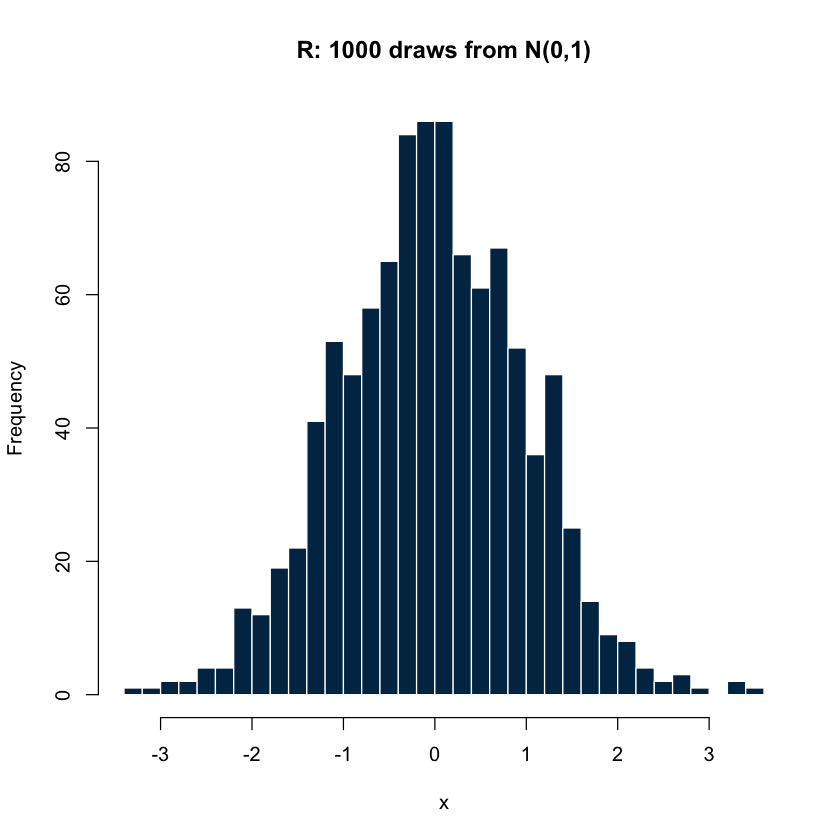

In [4]:
set.seed(42)
x <- rnorm(1000)

mean(x)
sd(x)
hist(x, breaks = 30, col = '#003153', border = 'white', main = 'R: 1000 draws from N(0,1)', xlab = 'x')

## 4. 循环与控制流

R 支持传统的 `for`/`while` 循环，但更推荐使用向量化操作和 `apply` 族函数。

## 4. 循环与控制流

R 支持传统的 `for`/`while` 循环，但更推荐使用向量化操作和 `apply` 族函数。

In [ ]:
# --- for 循环 ---
fruits <- c("苹果", "香蕉", "橙子")
for (fruit in fruits) {
  cat("我喜欢吃", fruit, "\n")
}

# 累加
total <- 0
for (i in 1:10) {
  total <- total + i
}
cat("1到10的和 =", total, "\n")

# --- while 循环 ---
n <- 1
while (n <= 5) {
  cat("当前 n =", n, "\n")
  n <- n + 1
}

# --- apply 族函数（R 的特色替代循环方案）---
# sapply: 对向量每个元素应用函数，返回向量
squares <- sapply(1:10, function(x) x^2)
cat("平方数:", squares, "\n")

# lapply: 返回列表（适用于复杂输出）
word_lengths <- lapply(c("Python", "Stata", "R"), nchar)
cat("单词长度:", unlist(word_lengths), "\n")

# tapply: 按分组应用函数
scores <- c(85, 90, 78, 92, 88, 75)
groups <- c("A", "A", "B", "B", "A", "B")
group_means <- tapply(scores, groups, mean)
print(group_means)

## 5. 函数的写法

R 中函数是"一等公民"，可以作为参数传递、赋值给变量。

In [ ]:
# --- 基本函数 ---
greet <- function(name) {
  paste0("你好，", name, "！")
}
cat(greet("同学"), "\n")

# --- 带默认参数 ---
power <- function(base, exp = 2) {
  base ^ exp
}
cat("3^2 =", power(3), "\n")
cat("2^10 =", power(2, 10), "\n")

# --- 返回多个值（用 list）---
desc_stats <- function(x) {
  list(
    mean = mean(x),
    sd   = sd(x),
    n    = length(x)
  )
}
result <- desc_stats(c(85, 90, 78, 92, 88))
cat(sprintf("均值=%.1f, 标准差=%.1f, 样本量=%d\n", 
            result$mean, result$sd, result$n))

# --- 匿名函数（R 4.1+ 简写语法）---
# 传统写法
sapply(1:5, function(x) x^2 + 1)

# R 4.1+ 简写（\(x) 等价于 function(x)）
sapply(1:5, \(x) x^2 + 1)

# --- 函数式编程：管道操作符 |> ---
c(3, 1, 4, 1, 5, 9) |> sort() |> rev() |> head(3)
# 相当于 head(rev(sort(c(3, 1, 4, 1, 5, 9))), 3)

## 6. 高级用法入门

### 6.1 ggplot2 的优势

`ggplot2` 基于"图形语法"（Grammar of Graphics），通过层层叠加构建图形，比 base R 更具系统性和美观度。

In [ ]:
# ggplot2: 图形语法的威力
library(ggplot2)

# 创建示例数据
set.seed(42)
df <- data.frame(
  x = rnorm(200),
  y = rnorm(200),
  group = sample(c("处理组", "对照组"), 200, replace = TRUE)
)

# 一行代码 = 散点图 + 分组着色 + 回归线 + 主题
ggplot(df, aes(x = x, y = y, color = group)) +
  geom_point(alpha = 0.6) +                    # 散点
  geom_smooth(method = "lm", se = TRUE) +       # 线性拟合 + 置信区间
  labs(title = "ggplot2 分组回归示例",
       x = "自变量", y = "因变量",
       color = "组别") +
  theme_minimal() +                             # 简洁主题
  scale_color_brewer(palette = "Set1")           # 配色方案

### 6.2 R 特色统计分析

R 在统计分析领域有丰富的原生支持，尤其是生存分析、混合效应模型、贝叶斯分析等。

In [ ]:
# --- 广义线性模型 (GLM) ---
# 逻辑回归：二分类
set.seed(42)
n <- 500
df_logit <- data.frame(
  x1 = rnorm(n),
  x2 = rnorm(n)
)
df_logit$y <- rbinom(n, 1, plogis(0.5 + 1.2 * df_logit$x1 - 0.8 * df_logit$x2))

model_logit <- glm(y ~ x1 + x2, data = df_logit, family = binomial)
summary(model_logit)

# --- 生存分析 (Survival Analysis) ---
library(survival)

# 使用内置 lung 数据集
data(lung)
# Kaplan-Meier 生存曲线
km_fit <- survfit(Surv(time, status) ~ sex, data = lung)
plot(km_fit, col = c("blue", "red"), 
     xlab = "时间（天）", ylab = "生存概率",
     main = "肺癌生存分析（按性别）")
legend("topright", c("男性", "女性"), col = c("blue", "red"), lty = 1)

# Cox 比例风险模型
cox_model <- coxph(Surv(time, status) ~ age + sex + ph.ecog, data = lung)
summary(cox_model)

### 6.3 R-Python 交互 (reticulate)

`reticulate` 包让你在 R 中无缝调用 Python，两种语言的对象可以互相传递。

In [ ]:
# R-Python 交互：reticulate
library(reticulate)

# 在 R 中调用 Python
py_run_string("
import math
result = math.sqrt(144)
message = f'Python 计算: sqrt(144) = {result}'
")

# 访问 Python 变量
cat("从 Python 取回:", py$message, "\n")
cat("值:", py$result, "\n")

# 直接用 Python 的 numpy
np <- import("numpy")
py_array <- np$array(c(1, 2, 3, 4, 5))
cat("NumPy 均值:", np$mean(py_array), "\n")
cat("NumPy 标准差:", np$std(py_array), "\n")

# R data.frame <-> pandas DataFrame 自动转换
r_df <- data.frame(name = c("张三", "李四"), score = c(90, 85))
py_run_string("
import pandas as pd
")
py$r_df_in_py <- r_df  # R -> Python
cat("类型检查: R data.frame 在 Python 中变为 pandas DataFrame\n")

In [ ]:
# R-Python 交互：reticulate
library(reticulate)

# 在 R 中调用 Python
py_run_string("
import math
result = math.sqrt(144)
message = f'Python 计算: sqrt(144) = {result}'
")

# 访问 Python 变量
cat("从 Python 取回:", py$message, "\n")
cat("值:", py$result, "\n")

# 直接用 Python 的 numpy
np <- import("numpy")
py_array <- np$array(c(1, 2, 3, 4, 5))
cat("NumPy 均值:", np$mean(py_array), "\n")
cat("NumPy 标准差:", np$std(py_array), "\n")

# R data.frame <-> pandas DataFrame 自动转换
r_df <- data.frame(name = c("张三", "李四"), score = c(90, 85))
py_run_string("
import pandas as pd
")
py$r_df_in_py <- r_df  # R -> Python
cat("类型检查: R data.frame 在 Python 中变为 pandas DataFrame\n")

## ✨ R 杀手锏预览：ggplot2 出版级可视化

R 最强大的能力之一是 **ggplot2** 的图形语法（Grammar of Graphics）系统。只需几行代码，就能从原始数据到出版级图表一气呵成——分组趋势、置信区间、标注、配色全部内建。

> 💡 **研究中的组合优势**：用 Stata 做计量回归 → 用 R 做高质量可视化 → 用 Python 做机器学习，这是实证研究的"铁三角"。

In [1]:
library(ggplot2)

# 模拟一个 DID 研究的数据
set.seed(42)
n <- 200
df_did <- data.frame(
  year = rep(2015:2024, each = n/10),
  group = rep(c("处理组", "对照组"), each = n/2),
  outcome = rnorm(n)
)
df_did$outcome <- df_did$outcome +
  ifelse(df_did$group == "处理组" & df_did$year >= 2020, 2.5, 0) +
  (df_did$year - 2015) * 0.3

# 分组均值趋势 + 置信区间 + 处理时点标注 — 一段代码搞定出版级图表
ggplot(df_did, aes(x = year, y = outcome, color = group, fill = group)) +
  stat_summary(fun = mean, geom = "line", linewidth = 1.2) +
  stat_summary(fun.data = mean_cl_normal, geom = "ribbon", alpha = 0.2, color = NA) +
  geom_vline(xintercept = 2019.5, linetype = "dashed", color = "gray40") +
  annotate("text", x = 2019.5, y = 5, label = "政策实施", hjust = -0.1, size = 4) +
  scale_color_manual(values = c("#003153", "#00A8CC")) +
  scale_fill_manual(values = c("#003153", "#00A8CC")) +
  labs(title = "双重差分：处理效应可视化",
       subtitle = "ggplot2 让分组趋势 + 置信区间 + 标注一气呵成",
       x = "年份", y = "结果变量", color = "", fill = "") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom")

ERROR: Error in library(ggplot2): there is no package called ‘ggplot2’


## 4. 练习

1. 把 `x <- rnorm(1000)` 改成均值 5、标准差 2。
2. 新建一列 `treated_outcome = treatment * outcome`。

In [5]:
# TODO: 在这里写你的练习代码